In [1]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [2]:
import math

In [ ]:
class value:
    def __init__(self,value, _children=(), _op='', label=''):
        self.data = value
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None
        self.label = label

    def __neg__(self):
        return self * -1
    
    def __add__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data + other.data, _children=(self, other), _op='+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __sub__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data - other.data, _children=(self, other), _op='-')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __mul__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data * other.data, _children=(self, other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        return self * other**-1

    
    def __radd__(self,other):
        return self + other
    
    def __rmul__(self,other):
        return self * other
    
    
    def __repr__(self):
        return f"value({self.data})"
    
    def exp(self):
        if not isinstance(self, value):
            self = value(self)
        
        x = self.data
        out = value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        if not isinstance(self, value):
            self = value(self)
        
        x = self.data
        out = value(x**other, (self,), f'pow{other}')

        def _backward():
            self.grad += other * (x**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        self.grad = 0.0
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

        out = value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):

        self.grad = 1.0
        # print(self.grad, self.label)
        topo = []
        visited = set()
        def build_topo(v):
            if v != None and v not in visited:
                # print(v.label)
                visited.add(v)
                for child in v._prev:
                    build_topo(child)#dfs

                # print(v.label)
                topo.append(v)

        build_topo(self)
        topo = topo[::-1]
        for node in topo:
            # print(node.label)
            node._backward()

In [54]:
a = value(3.0)
a = a.tanh()
print(a.data)

print(math.tanh(3))

0.9950547536867305
0.9950547536867305


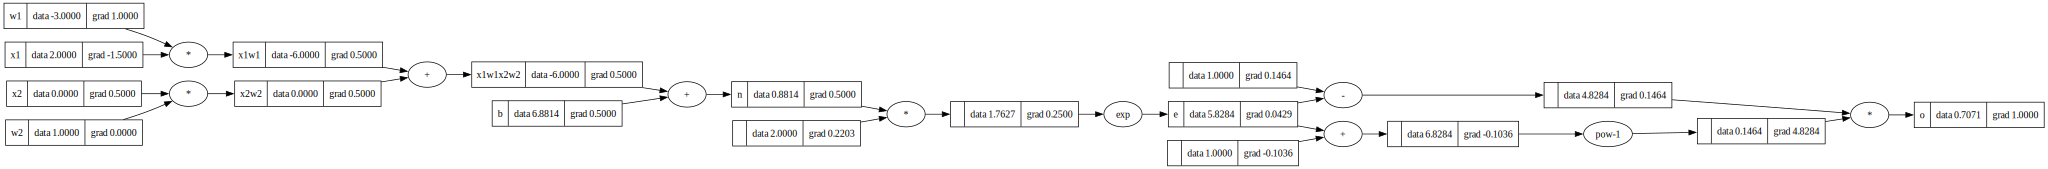

In [56]:
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2') 

w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

b = value(6.881373587019543, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
# ----
e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# x1w1 = w1 * x1; x1w1.label = 'x1w1'
# x2w2 = w2 * x2; x2w2.label = 'x2w2'
# x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
o.backward()

# draw_dot(o)

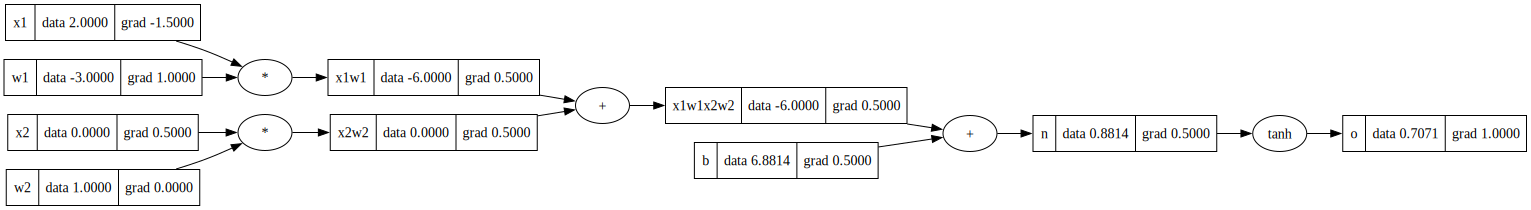

In [ ]:
draw_dot(o)

In [59]:
import torch

In [60]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [61]:
import random

In [62]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [63]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

value(-0.6956382260386145)

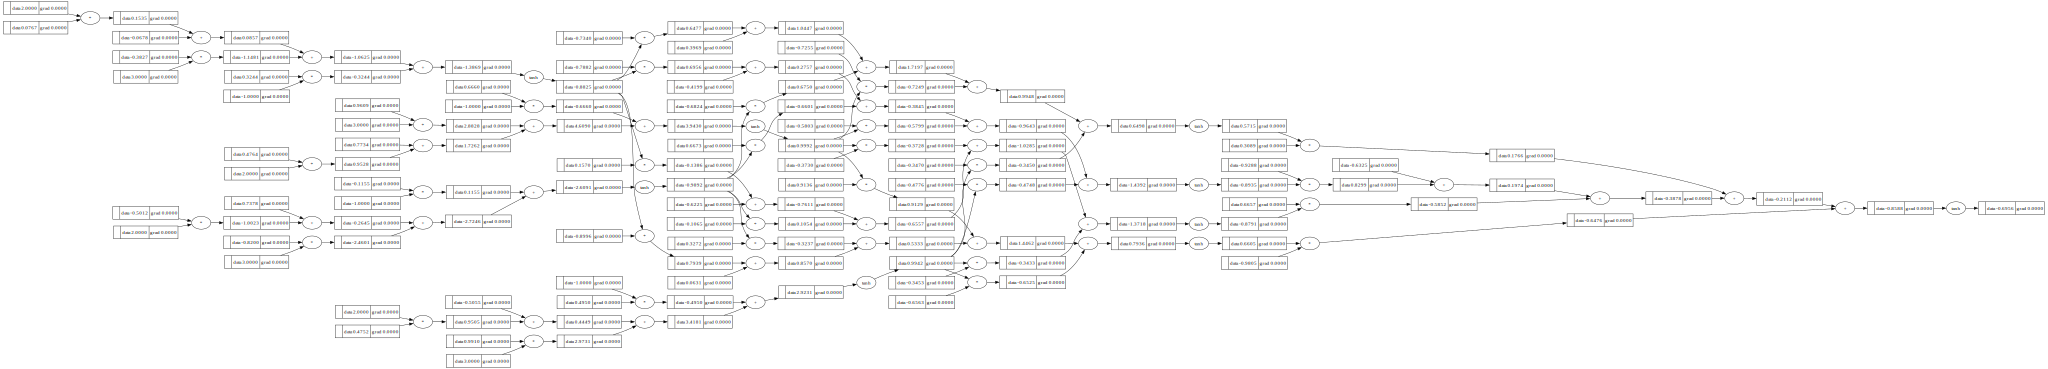

In [64]:
draw_dot(n(x))

In [65]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
for k in range(1000):
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # += in all backward passes so we have to reset the gradients to zero before each backward pass first then we can do the backward pass
  loss.backward()
  
  # update
  for p in n.parameters():
    # on the basis of the gradients we have to update the weights and biases
    p.data += -0.1 * p.grad
  
  print(k, loss.data)
  

0 0.0018825372054003574
1 0.0018653256020948847
2 0.001848418098710144
3 0.0018318068228835005
4 0.001815484169054712
5 0.001799442787335757
6 0.0017836755729304177
7 0.0017681756560721305
8 0.0017529363924510162
9 0.0017379513541026573
10 0.0017232143207328355
11 0.0017087192714542792
12 0.0016944603769129683
13 0.0016804319917824726
14 0.0016666286476069144
15 0.0016530450459736183
16 0.0016396760519979945
17 0.0016265166881042352
18 0.0016135621280862333
19 0.001600807691434288
20 0.0015882488379137982
21 0.0015758811623830349
22 0.0015637003898378373
23 0.001551702370671796
24 0.0015398830761411003
25 0.0015282385940237938
26 0.0015167651244638951
27 0.0015054589759913237
28 0.0014943165617089067
29 0.0014833343956385148
30 0.0014725090892186241
31 0.0014618373479460146
32 0.001451315968154805
33 0.0014409418339263107
34 0.00143071191412361
35 0.0014206232595450235
36 0.0014106730001909717
37 0.0014008583426389845
38 0.001391176567521939
39 0.001381625027104898
40 0.001372201142955